In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,ConfusionMatrixDisplay

In [ ]:
#load iris dataset
iris=load_iris()
iris_def=pd.DataFrame(iris.data, columns=iris.feature_names)
iris_def['species']=iris.target #add the target column
iris_def['species']=iris_def['species'].map({
    0:'Setosa',
    1:'Versicolor',
    2:'Virginica'
})
print(iris_def)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

       species  
0       Se

In [ ]:
#basic checks

In [ ]:
iris_def.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
iris_def.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [ ]:
iris_def.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
iris_def.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris_def.shape

(150, 5)

In [ ]:
iris_def.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


In [ ]:
iris_def['species'].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


In [ ]:
#check null values
iris_def.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
iris_def.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
145,False
146,False
147,False
148,False


# **Data Visualization**

Text(0.5, 1.02, 'Pairplot of Iris Features by Species ')

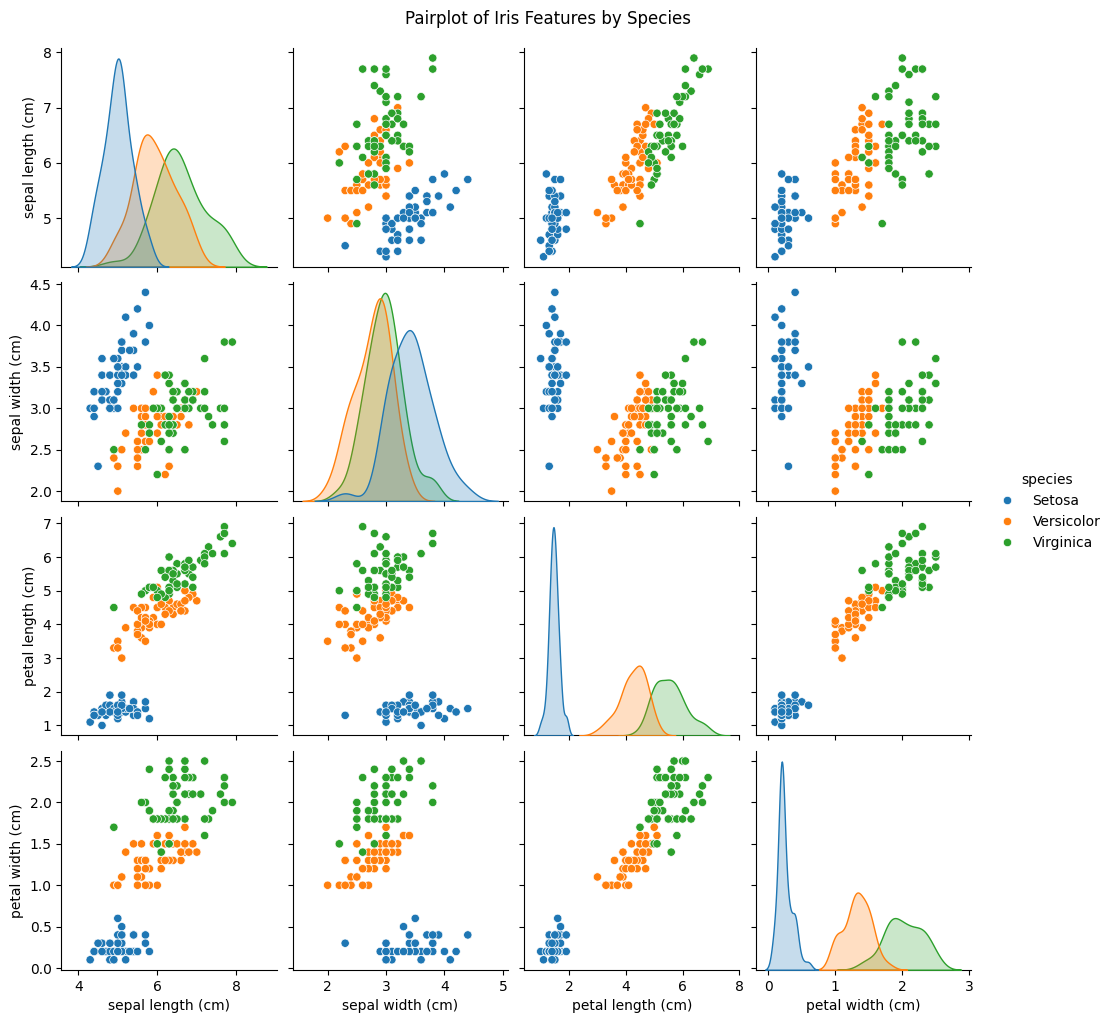

In [ ]:
sns.pairplot(iris_def,hue='species')
plt.suptitle("Pairplot of Iris Features by Species ",y=1.02)

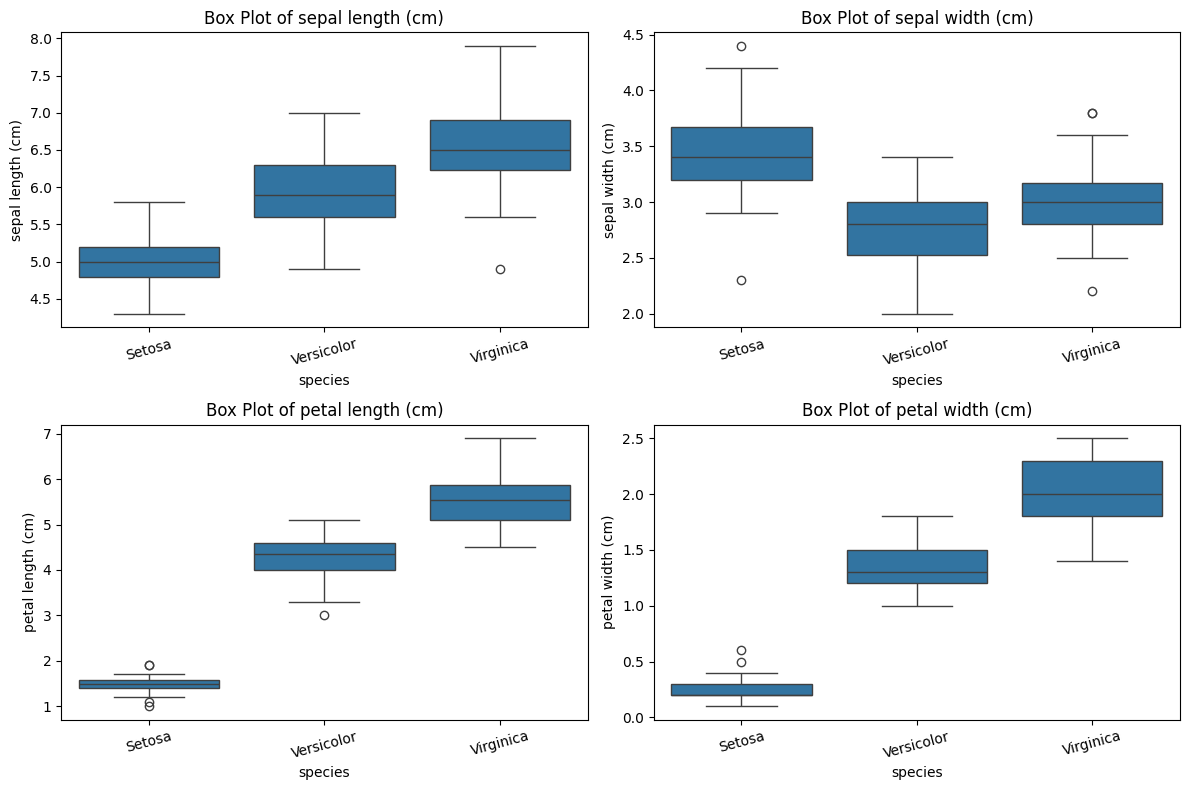

In [ ]:
# Select numerical features
features = iris.feature_names

# Create box plots
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=iris_def,
        x="species",
        y=feature
    )
    plt.title(f"Box Plot of {feature}")
    plt.xticks(rotation=15)

plt.tight_layout()

Based on the pairplot and box plots, petal length and petal width appear to be the most discriminative features because they show clearer separation between the three iris species. Sepal length and sepal width show more overlap.

In [ ]:
#select input features and target
X=iris_def[iris.feature_names]
y=iris_def['species']

In [ ]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


# **Logistic Regression**

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [ ]:
#create model
lr_model=LogisticRegression(max_iter=200)

#train the model
lr_model.fit(X_train,y_train)


LogisticRegression(max_iter=200)

In [ ]:
#make predictions
y_pred=lr_model.predict(X_test)

In [ ]:
#calculate accuracy
lr_accuracy=accuracy_score(y_test,y_pred)
print("Logistic Regression Accuracy",lr_accuracy)

Logistic Regression Accuracy 0.9666666666666667


In [ ]:
#classification report of logistic regression
print("Classification Report")
print(classification_report(y_test,y_pred))

Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
#confusion matrix of logistic regression
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


Logistic Regression achieved an accuracy of 97% on the test dataset. It classified all Setosa and Virginica samples correctly in terms of recall, while it correctly identified 9 out of 10 Versicolor samples. Overall, the model demonstrated strong classification performance.

# **K-NearesT_Neighbours (KNN)**

In [ ]:
#create KNN model
knn=KNeighborsClassifier(n_neighbors=5)

In [ ]:
#train knn model
knn.fit(X_train,y_train)

#predictions
y_pred_knn=knn.predict(X_test)

In [ ]:
#calculate accuracy
knn_accuracy=accuracy_score(y_test,y_pred_knn)
print("KNN Accuracy",knn_accuracy)

KNN Accuracy 1.0


In [ ]:
print("Classification Report")
print(classification_report(y_test,y_pred_knn))

Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
#confusion Mtrix of KNN
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred_knn))

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [ ]:
#comparision table between logistic regression and KNN
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [lr_accuracy, knn_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.966667
1,KNN,1.000000


Logistic Regression achieved an accuracy of approximately 0.96%, misclassifying one Versicolor flower as Virginica. KNN correctly classified all 30 test samples and achieved 100% accuracy on this test set. Therefore, KNN performed better on this particular train-test split.

# **Best Model**

KNN performed better than Logistic Regression on this particular
train-test split because it achieved higher accuracy and correctly
classified every test sample.

However, the dataset is small, so model performance may vary with
different train-test splits.